# Few-Shot Day-to-Night Translation: Main-Grid Analysis

This notebook compares Pix2Pix-Turbo and CycleGAN-Turbo across all shot levels present in the RTX 5090 results. The original 10/20/50-shot main grid is supplemented by a post-hoc exploratory 5-shot extension. All runs use the same deterministic 200-image held-out test subset.

**Breaking-point definition.** For a lower shot level $L$ and the next higher level $H$, we require (1) a significant degradation in the direction of worse performance at $L$ relative to $H$, and (2) increased variability at $L$ across seeds and, when the full artifact is available, across test samples.

- If breaking points are observed at multiple shot-levels, we consider the highest low-shot setting at which instability first emerges as supervision is reduced as the formal breaking point.

## Quantitative comparison

Each metric gets one panel, with both models on the same axes. Lines emphasize the shot trajectory better than grouped bars; error bars show **standard deviation across the three training seeds**, and faint points expose the individual seed values. Metric direction is shown in each title.

In [ ]:
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
print(f"Kernel: {sys.executable}", flush=True)
print("Loading NumPy and Pandas ...", flush=True)
_load_started = time.perf_counter()
import numpy as np
import pandas as pd

print(f"Core imports loaded in {time.perf_counter() - _load_started:.2f}s", flush=True)


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (
            candidate
            / "results"
            / "full_grid_official_cmmd"
            / "evaluation"
            / "runs.csv"
        ).is_file():
            return candidate
        # local results folder
        if (candidate / "results_5090" / "runs.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find results/full_grid_official_cmmd/evaluation/runs.csv"
    )


ROOT = find_project_root()
uploaded = False
RESULTS = (
    ROOT / "results_5090"
    if uploaded
    else ROOT / "results" / "full_grid_official_cmmd" / "evaluation"
)
runs = pd.read_csv(RESULTS / "runs.csv")
aggregate = pd.read_csv(RESULTS / "aggregate.csv")

SHOTS = sorted(runs["shot"].unique().tolist())
ADJACENT_SHOTS = list(zip(SHOTS[:-1], SHOTS[1:]))
MODELS = ["pix2pix", "cyclegan"]
MODEL_LABELS = {"pix2pix": "Pix2Pix-Turbo", "cyclegan": "CycleGAN-Turbo"}
MODEL_COLORS = {"pix2pix": "#2C7FB8", "cyclegan": "#E76F51"}
METRICS = {
    "ssim": {"label": "SSIM", "higher_is_better": True},
    "lpips": {"label": "LPIPS", "higher_is_better": False},
    "clip_similarity": {"label": "CLIP similarity", "higher_is_better": True},
    "cmmd": {"label": "CMMD (official, sigma=10)", "higher_is_better": False},
}

assert SHOTS, "No shot levels found in runs.csv"
assert set(runs["model"]) == set(MODELS)
assert runs.groupby(["model", "shot"])["seed"].nunique().eq(3).all()
coverage = (
    runs.groupby(["model", "shot"], as_index=False)
    .agg(num_seeds=("seed", "nunique"), samples_per_seed=("num_samples", "first"))
    .sort_values(["model", "shot"])
)
display(coverage)

Kernel: e:\miniconda3\envs\ml\python.exe
Loading NumPy and Pandas ...
Core imports loaded in 0.00s


,model,shot,num_seeds,samples_per_seed
0,cyclegan,5,3,200
1,cyclegan,10,3,200
2,cyclegan,20,3,200
3,cyclegan,50,3,200
4,pix2pix,5,3,200
5,pix2pix,10,3,200
6,pix2pix,20,3,200
7,pix2pix,50,3,200


Loading plotting libraries ...
Plotting libraries loaded in 0.00s


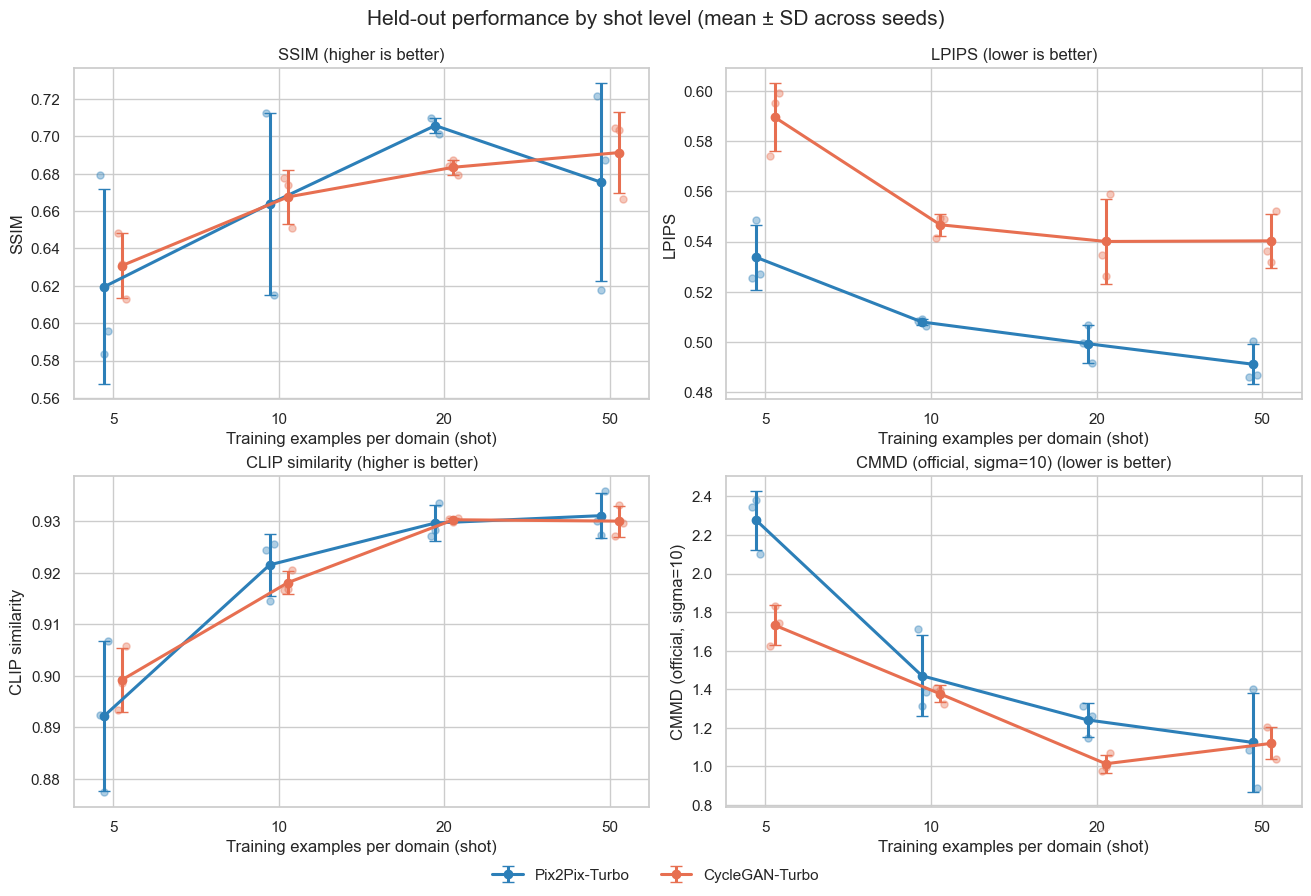

In [19]:
print("Loading plotting libraries ...", flush=True)
_plot_started = time.perf_counter()
import matplotlib.pyplot as plt
import seaborn as sns

print(
    f"Plotting libraries loaded in {time.perf_counter() - _plot_started:.2f}s",
    flush=True,
)

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)
x = np.arange(len(SHOTS))
offsets = {"pix2pix": -0.055, "cyclegan": 0.055}

for ax, (metric, meta) in zip(axes.flat, METRICS.items()):
    for model in MODELS:
        summary = (
            aggregate[(aggregate["model"] == model) & (aggregate["metric"] == metric)]
            .set_index("shot")
            .loc[SHOTS]
        )
        seed_rows = runs[runs["model"] == model]
        positions = x + offsets[model]
        ax.errorbar(
            positions,
            summary["mean"],
            yerr=summary["std_across_seeds"],
            color=MODEL_COLORS[model],
            marker="o",
            linewidth=2.2,
            capsize=4,
            label=MODEL_LABELS[model],
            zorder=3,
        )
        for index, shot in enumerate(SHOTS):
            values = seed_rows.loc[seed_rows["shot"] == shot, metric].to_numpy()
            jitter = np.linspace(-0.025, 0.025, len(values))
            ax.scatter(
                np.full(len(values), positions[index]) + jitter,
                values,
                s=26,
                color=MODEL_COLORS[model],
                alpha=0.38,
                zorder=2,
            )
    direction = (
        "higher is better" if meta["higher_is_better"] else "lower is better"
    )
    ax.set_title(f"{meta['label']} ({direction})")
    ax.set_xticks(x, SHOTS)
    ax.set_xlabel("Training examples per domain (shot)")
    ax.set_ylabel(meta["label"])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle(
    "Held-out performance by shot level (mean ± SD across seeds)", y=1.04, fontsize=15
)
plt.show()
plt.close(fig)

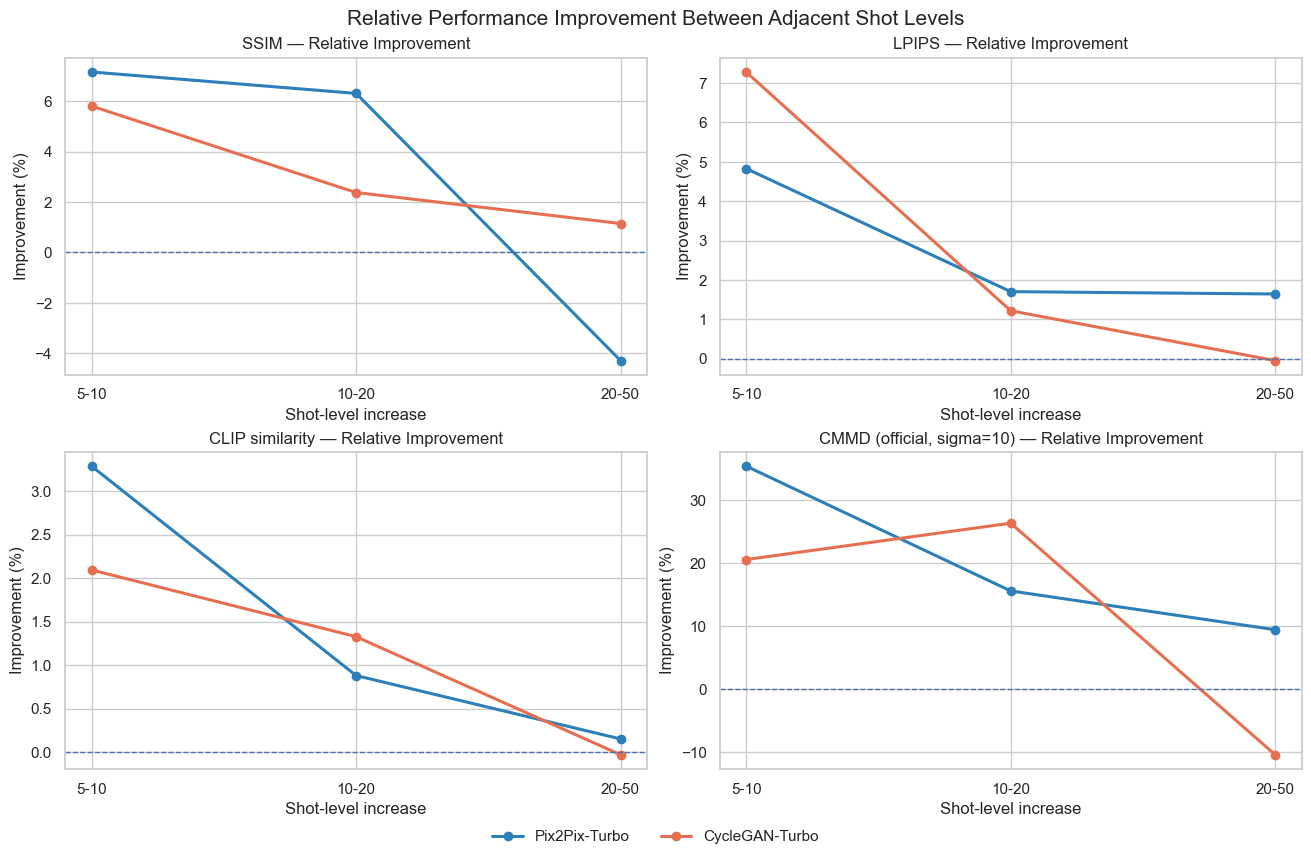

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)

for ax, (metric, meta) in zip(axes.flat, METRICS.items()):
    for model in MODELS:
        # Mean performance across seeds at each shot level
        model_data = (
            runs[runs["model"] == model].groupby("shot")[metric].mean().loc[SHOTS]
        )

        improvements = []

        for low, high in ADJACENT_SHOTS:
            low_mean = model_data.loc[low]
            high_mean = model_data.loc[high]

            # Make positive values mean "improvement"
            if meta["higher_is_better"]:
                improvement = (high_mean - low_mean) / abs(low_mean) * 100
            else:
                improvement = (low_mean - high_mean) / abs(low_mean) * 100

            improvements.append(improvement)

        labels = [f"{low}-{high}" for low, high in ADJACENT_SHOTS]

        ax.plot(
            labels,
            improvements,
            marker="o",
            linewidth=2.2,
            color=MODEL_COLORS[model],
            label=MODEL_LABELS[model],
        )

    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"{meta['label']} — Relative Improvement")
    ax.set_xlabel("Shot-level increase")
    ax.set_ylabel("Improvement (%)")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)

fig.suptitle(
    "Relative Performance Improvement Between Adjacent Shot Levels", fontsize=15
)

plt.show()
plt.close(fig)

- Performance gains are largest when increasing the training set from 5 to 10 shots. Although additional examples continue to improve performance between 10 and 20 shots, the gains are considerably smaller. Beyond 20 shots, improvements largely plateau and occasionally become negative, suggesting diminishing returns from additional training data.

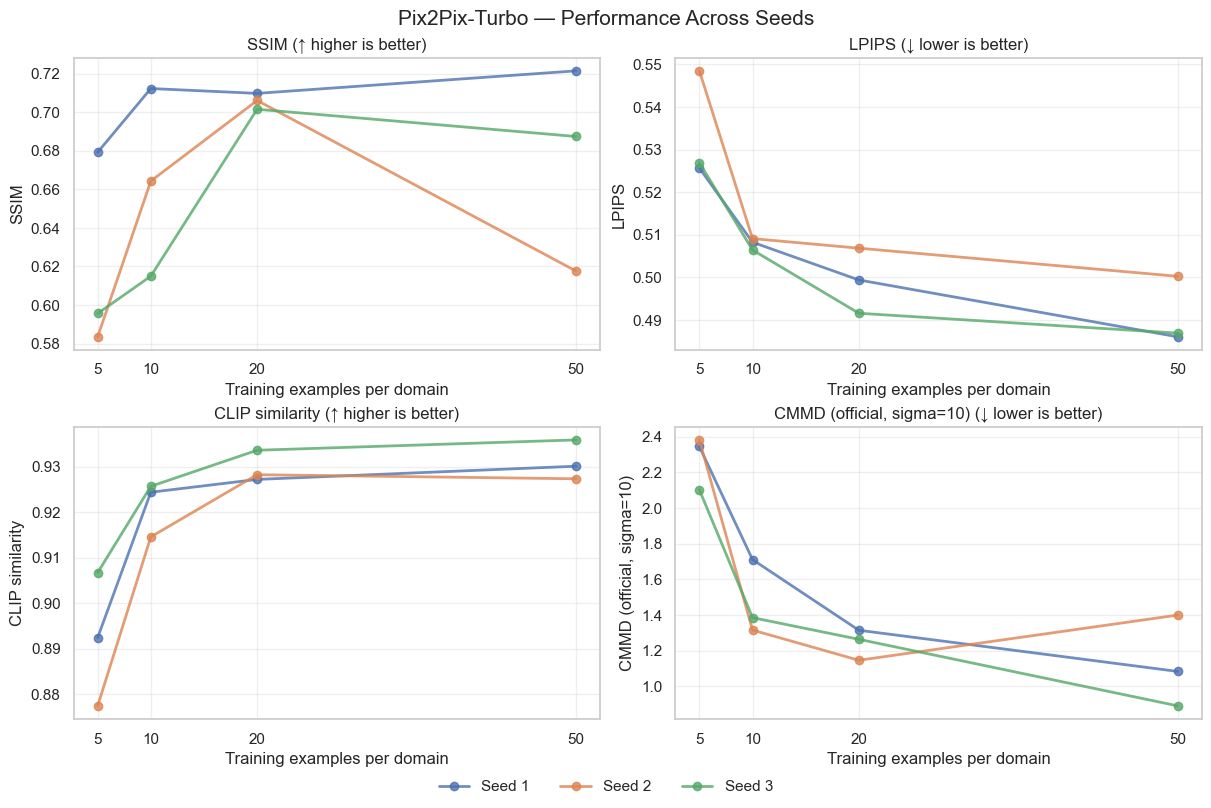

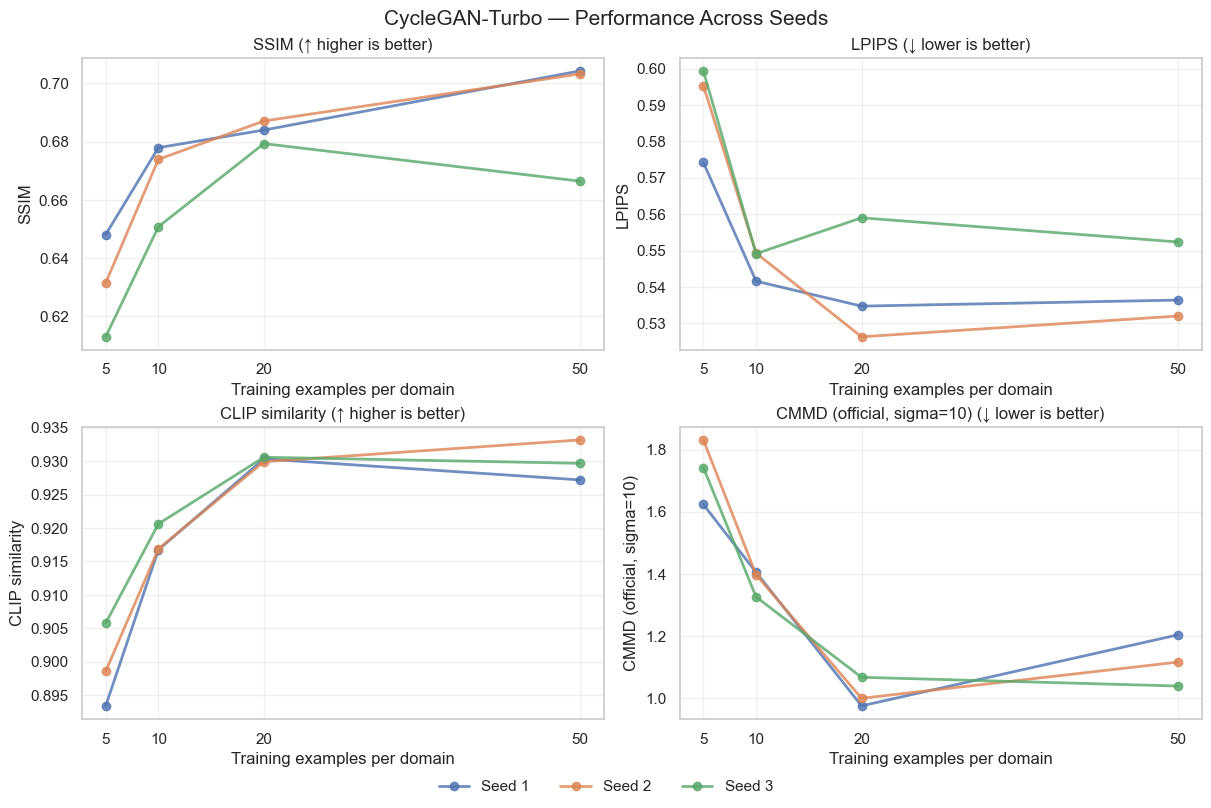

In [17]:
for model in MODELS:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    model_data = runs[runs["model"] == model]

    for ax, (metric, meta) in zip(axes.flat, METRICS.items()):
        seeds = sorted(model_data["seed"].unique())

        for seed in seeds:
            seed_data = (
                model_data[model_data["seed"] == seed]
                .set_index("shot")[metric]
                .loc[SHOTS]
            )

            ax.plot(
                SHOTS,
                seed_data.values,
                marker="o",
                linewidth=2,
                alpha=0.8,
                label=f"Seed {seed}",
            )

        direction = (
            "↑ higher is better" if meta["higher_is_better"] else "↓ lower is better"
        )

        ax.set_title(f"{meta['label']} ({direction})")
        ax.set_xlabel("Training examples per domain")
        ax.set_ylabel(meta["label"])
        ax.set_xticks(SHOTS)
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)

    fig.suptitle(f"{MODEL_LABELS[model]} — Performance Across Seeds", fontsize=15)

    plt.show()
    plt.close(fig)

- At 5 shots, both models show substantial variation across seeds, whereas the seed results become more closely grouped at 10–20 shots. This suggests that increasing the training set improves run-to-run stability under the current experimental setup.

- Pix2Pix-Turbo exhibits high sensitivity to the random seed in SSIM, with substantial variation across seeds even at 50 shots. This suggests that its structural preservation remains sensitive to training randomness despite having more training data.

## Breaking-point screen

For each adjacent shot pair found in the results (including 5 vs. 10 when the exploratory extension is present), metric values are oriented so that larger always means better. A positive `degradation` therefore means the lower-shot setting is worse. The mean comparison uses a one-sided paired t-test across matching seed IDs. `seed_variance_ratio > 1` means the lower-shot setting is more variable.

Because there are only three seeds, these tests have low power and should be treated as exploratory. Both raw p-values and Holm-adjusted p-values (within each model's 12 adjacent-shot tests: four metrics across three transitions) are reported.

In [ ]:
print("Loading SciPy statistics ...", flush=True)
_stats_started = time.perf_counter()
from scipy.stats import ttest_rel

print(f"SciPy loaded in {time.perf_counter() - _stats_started:.2f}s", flush=True)


def holm_adjust(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running_max = 0.0
    total = len(values)
    for rank, index in enumerate(order):
        running_max = max(running_max, (total - rank) * values[index])
        adjusted[index] = min(running_max, 1.0)
    return adjusted


rows = []
for model in MODELS:
    model_runs = runs[runs["model"] == model]
    for metric, meta in METRICS.items():
        pivot = model_runs.pivot(index="seed", columns="shot", values=metric)
        sign = 1.0 if meta["higher_is_better"] else -1.0
        for low_shot, high_shot in ADJACENT_SHOTS:
            low = sign * pivot[low_shot]
            high = sign * pivot[high_shot]
            degradation = float((high - low).mean())
            test = ttest_rel(high, low, alternative="greater")
            high_variance = float(high.var(ddof=1))
            low_variance = float(low.var(ddof=1))
            variance_ratio = (
                low_variance / high_variance if high_variance > 0 else np.inf
            )
            rows.append(
                {
                    "model": model,
                    "metric": metric,
                    "comparison": f"{low_shot} vs {high_shot}",
                    "low_shot": low_shot,
                    "high_shot": high_shot,
                    "degradation": degradation,
                    "p_raw": float(test.pvalue),
                    "seed_variance_ratio": variance_ratio,
                }
            )

breaking = pd.DataFrame(rows)
breaking["p_holm"] = breaking.groupby("model")["p_raw"].transform(holm_adjust)
breaking["mean_degrades"] = breaking["degradation"] > 0
breaking["raw_significant"] = breaking["mean_degrades"] & (breaking["p_raw"] < 0.05)
breaking["holm_significant"] = breaking["mean_degrades"] & (breaking["p_holm"] < 0.05)
breaking["seed_variance_increases"] = breaking["seed_variance_ratio"] > 1
breaking["seed_level_candidate"] = (
    breaking["raw_significant"] & breaking["seed_variance_increases"]
)
breaking_seed = breaking.copy()

display(
    breaking.sort_values(["model", "metric", "low_shot"]).style.format(
        {
            "degradation": "{:.4f}",
            "p_raw": "{:.4f}",
            "p_holm": "{:.4f}",
            "seed_variance_ratio": "{:.2f}",
        }
    )
)

Loading SciPy statistics ...
SciPy loaded in 0.00s


,model,metric,comparison,low_shot,high_shot,degradation,p_raw,seed_variance_ratio,p_holm,mean_degrades,raw_significant,holm_significant,seed_variance_increases,seed_level_candidate
18,cyclegan,clip_similarity,5 vs 10,5,10,0.0188,0.0084,7.99,0.0753,True,True,False,True,True
19,cyclegan,clip_similarity,10 vs 20,10,20,0.0122,0.0042,42.16,0.0507,True,True,False,True,True
20,cyclegan,clip_similarity,20 vs 50,20,50,-0.0003,0.5490,0.01,1.0000,False,False,False,False,False
21,cyclegan,cmmd,5 vs 10,5,10,0.3565,0.0178,5.68,0.1249,True,True,False,True,True
22,cyclegan,cmmd,10 vs 20,10,20,0.3626,0.0102,0.84,0.0817,True,True,False,False,False
23,cyclegan,cmmd,20 vs 50,20,50,-0.1058,0.8545,0.33,1.0000,False,False,False,False,False
15,cyclegan,lpips,5 vs 10,5,10,0.0429,0.0075,9.38,0.0747,True,True,False,True,True
16,cyclegan,lpips,10 vs 20,10,20,0.0067,0.2774,0.07,1.0000,True,False,False,False,False
17,cyclegan,lpips,20 vs 50,20,50,-0.0002,0.5239,2.51,1.0000,False,False,False,True,False
12,cyclegan,ssim,5 vs 10,5,10,0.0367,0.0049,1.43,0.0542,True,True,False,True,True


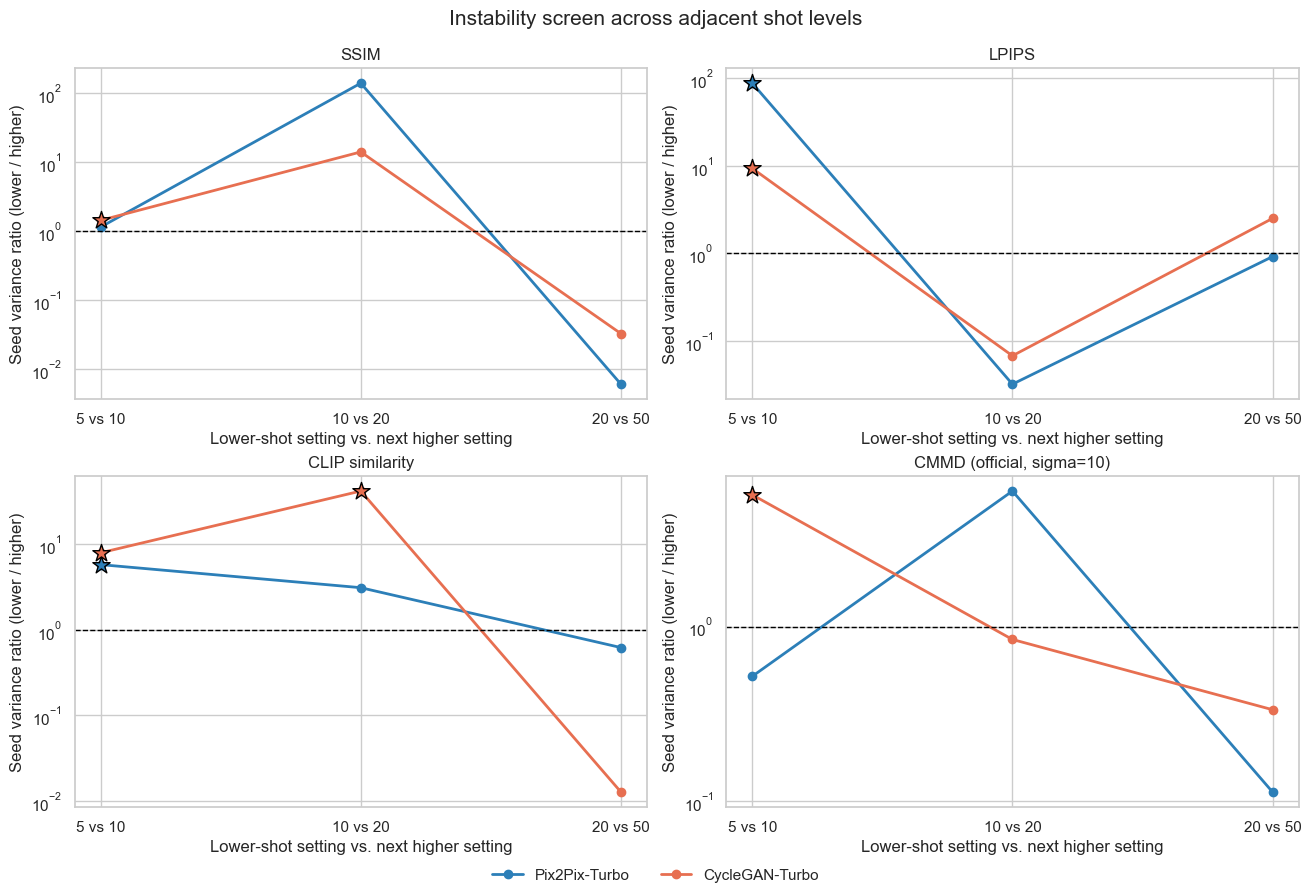

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)
for ax, (metric, meta) in zip(axes.flat, METRICS.items()):
    subset = breaking[breaking["metric"] == metric]
    for model in MODELS:
        model_rows = subset[subset["model"] == model].sort_values("low_shot")
        ax.plot(
            model_rows["comparison"],
            model_rows["seed_variance_ratio"],
            marker="o",
            linewidth=2,
            color=MODEL_COLORS[model],
            label=MODEL_LABELS[model],
        )
        candidates = model_rows["seed_level_candidate"]
        ax.scatter(
            model_rows.loc[candidates, "comparison"],
            model_rows.loc[candidates, "seed_variance_ratio"],
            marker="*",
            s=170,
            color=MODEL_COLORS[model],
            edgecolor="black",
            zorder=4,
        )
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_yscale("log")
    ax.set_title(meta["label"])
    ax.set_xlabel("Lower-shot setting vs. next higher setting")
    ax.set_ylabel("Seed variance ratio (lower / higher)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("Instability screen across adjacent shot levels", y=1.04, fontsize=15)
plt.show()
plt.close(fig)

### Optional test-sample variance

The official evaluation archive contains one mean per seed plus the per-sample SSIM, LPIPS, and CLIP values used for within-test-sample variance. The next cell loads `results/full_grid_official_cmmd/evaluation/*/*shot/seed*/per_sample_metrics.csv`. CMMD remains distribution-level and has no per-sample value.

In [ ]:
evaluation_root = ROOT / "results" / "full_grid_official_cmmd" / "evaluation"
sample_files = sorted(evaluation_root.glob("*/*shot/seed*/per_sample_metrics.csv"))

if not sample_files:
    print(
        "Per-sample files not found. Extract the full artifact under "
        "results/full_grid_official_cmmd/evaluation to complete criterion (2)."
    )
else:
    print(f"Reading {len(sample_files)} per-sample metric files ...", flush=True)
    metric_names = ("ssim", "lpips", "clip_similarity")
    variance_rows = []
    for path in sample_files:
        relative = path.relative_to(evaluation_root)
        model, shot_folder, seed_folder = relative.parts[:3]
        frame = pd.read_csv(path, usecols=list(metric_names))
        for metric in metric_names:
            variance_rows.append(
                {
                    "model": model,
                    "shot": int(shot_folder.removesuffix("shot")),
                    "seed": int(seed_folder.removeprefix("seed")),
                    "metric": metric,
                    "within_seed_variance": frame[metric].var(ddof=1),
                }
            )
    within_seed = (
        pd.DataFrame(variance_rows)
        .groupby(["model", "shot", "metric"])["within_seed_variance"]
        .mean()
    )
    print("Per-sample variances computed.", flush=True)

    sample_rows = []
    for metric in metric_names:
        for model in MODELS:
            for low_shot, high_shot in ADJACENT_SHOTS:
                low_variance = within_seed.loc[(model, low_shot, metric)]
                high_variance = within_seed.loc[(model, high_shot, metric)]
                sample_rows.append(
                    {
                        "model": model,
                        "metric": metric,
                        "low_shot": low_shot,
                        "sample_variance_ratio": low_variance / high_variance,
                    }
                )

    sample_variance = pd.DataFrame(sample_rows)
    breaking = breaking_seed.merge(
        sample_variance, on=["model", "metric", "low_shot"], how="left"
    )
    breaking["sample_variance_status"] = np.select(
        [
            breaking["sample_variance_ratio"].isna(),
            breaking["sample_variance_ratio"] > 1,
        ],
        ["N/A (distribution-level metric)", "increases"],
        default="does not increase",
    )
    breaking["full_breaking_point_evidence"] = pd.Series(
        pd.NA, index=breaking.index, dtype="boolean"
    )
    sample_available = breaking["sample_variance_ratio"].notna()
    breaking.loc[sample_available, "full_breaking_point_evidence"] = (
        breaking.loc[sample_available, "raw_significant"]
        & breaking.loc[sample_available, "seed_variance_increases"]
        & (breaking.loc[sample_available, "sample_variance_ratio"] > 1)
    )
    compact_columns = [
        "model",
        "metric",
        "comparison",
        "degradation",
        "p_raw",
        "p_holm",
        "seed_variance_ratio",
        "sample_variance_ratio",
        "sample_variance_status",
        "full_breaking_point_evidence",
    ]
    compact = breaking.sort_values(["model", "metric", "low_shot"])[
        compact_columns
    ].copy()
    for column in (
        "degradation",
        "p_raw",
        "p_holm",
        "seed_variance_ratio",
        "sample_variance_ratio",
    ):
        compact[column] = compact[column].round(4)
    display(compact.reset_index(drop=True))

Reading 24 per-sample metric files ...
Per-sample variances computed.


,model,metric,comparison,degradation,p_raw,p_holm,seed_variance_ratio,sample_variance_ratio,sample_variance_status,full_breaking_point_evidence
0,cyclegan,clip_similarity,5 vs 10,0.0188,0.0084,0.0753,7.9918,1.0642,increases,True
1,cyclegan,clip_similarity,10 vs 20,0.0122,0.0042,0.0507,42.1564,1.2489,increases,True
2,cyclegan,clip_similarity,20 vs 50,-0.0003,0.5490,1.0000,0.0127,0.7650,does not increase,False
3,cyclegan,cmmd,5 vs 10,0.3565,0.0178,0.1249,5.6802,NaN,N/A (distribution-level metric),<NA>
4,cyclegan,cmmd,10 vs 20,0.3626,0.0102,0.0817,0.8435,NaN,N/A (distribution-level metric),<NA>
5,cyclegan,cmmd,20 vs 50,-0.1058,0.8545,1.0000,0.3341,NaN,N/A (distribution-level metric),<NA>
6,cyclegan,lpips,5 vs 10,0.0429,0.0075,0.0747,9.3793,1.5290,increases,True
7,cyclegan,lpips,10 vs 20,0.0067,0.2774,1.0000,0.0676,1.2378,increases,False
8,cyclegan,lpips,20 vs 50,-0.0002,0.5239,1.0000,2.5129,0.9193,does not increase,False
9,cyclegan,ssim,5 vs 10,0.0367,0.0049,0.0542,1.4349,0.9843,does not increase,False


## Interpretation guidance

- Treat a metric-specific shot level as a **descriptive instability candidate** when the raw paired test shows degradation and the seed variance ratio exceeds 1.
- Call it a **formal breaking point** only when the claim is also supported by test-sample variability and remains credible after accounting for multiple comparisons.
- With only three seeds, failure to reach significance is not evidence that the models are stable; report effect direction, variance ratios, and uncertainty alongside p-values.
- Do not pool 600 sample rows as if they were 600 independent training runs. Images are repeated across seeds and shot levels, so per-sample evidence must remain grouped by seed.
- Use the same 200 filenames for every model/shot/seed comparison, as enforced by the generation manifests.

## Human qualitative evaluation

To complement the quantitative breaking-point analysis, score a filename-matched subset blind to model and shot level. Use the same images across all conditions and randomize presentation order.

| Aspect | Score (1–5) | Evaluation focus |
| :--- | :--- | :--- |
| **Instruction following / content preservation** | 1 = major content mismatch; 5 = core scene content preserved while following the day-to-night instruction | Whether vehicles, roads, signs, and scene layout remain faithful to the input |
| **Physical and spatial logic** | 1 = severe geometry/physics errors; 5 = natural and coherent scene | Road geometry, vehicle structure, lighting placement, and spatial consistency |
| **Visual quality** | 1 = severe blur/noise/artifacts; 5 = sharp and natural | Artifacts, sharpness, color, exposure, and local texture |
| **Night realism** | 1 = not convincingly nighttime; 5 = realistic nighttime appearance | Darkness, illumination, headlights, shadows, and overall atmosphere |